In [1]:
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from shapely import wkt
import libpysal
import mapclassify

 - Conserver les données de 2020 à 2024 => Correspondant à la période pour le calcul de l'indice de vulnérabilité
 - Vérifier les corrélations avec dette / budget
 - Etablir une cartographie sur les évolutions des impots de 2020 à 2024
 - Cibler des communes ayant subies le plus de CatNat sur cette période pour voir si les évolutions d'impots sont importantes

<h1 style = "color: green; text-align: center">Import des données</h1>

In [2]:
ODIS_DUCKDB_FILE = "odis.duckdb"
PCC_DUCKDB_FILE = "dev.duckdb"

con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
con.sql(f"ATTACH '{ODIS_DUCKDB_FILE}' AS odis;")

In [3]:
query_geo = """
SELECT
	*

FROM dev.main.opendatasoft_communes

"""

geo = con.sql(query_geo)
df = geo.df()

df.head(2)

,code_geo,nom_commune,code_geo_actuel,nom_commune_majuscule,nom_commune_minuscule,code_zone_superficie,type_commune,code_siren,zone_montagne,code_departement,...,code_arrondissement_departemental,nom_arrondissement_departemental,code_epci,nom_epci,code_zone_emploi_2020,nom_zone_emploi_2020,code_bassin_vie_2022,nom_bassin_vie_2022,geo_point_2_d,geometry
0,23048,Champagnat,23048,CHAMPAGNAT,champagnat,FXX,commune,212304802,Non,23,...,231,Aubusson,200067593,Communauté de communes Marche et Combraille en...,7511,Guéret,23008,Aubusson,"{ ""lon"": 2.2867022671589505, ""lat"": 46.0201583...",POLYGON ((2.277926679407017 45.990846410913235...
1,23080,Féniers,23080,FÉNIERS,féniers,FXX,commune,212308001,Oui,23,...,231,Aubusson,200066744,Communauté de communes Haute-Corrèze Communauté,7511,Guéret,19275,Ussel,"{ ""lon"": 2.1265431779148565, ""lat"": 45.7442741...","POLYGON ((2.156567154216348 45.72163356871487,..."


In [4]:
query_budget = """
SELECT
    annee, code_geo, nom_com, type_compte, solde

FROM dev.main.budget_per_compte_communes

"""

budget = con.sql(query_budget)
df2 = budget.df()

df2.head(2)



,annee,code_geo,nom_com,type_compte,solde
0,2017,02269,Sari-Solenzara,dettes,-646099.15
1,2017,02140,Lento,dettes,-93207.91


In [5]:
df1 = pd.read_csv("ofgl_impots_locaux.csv")
df1.head(2)

/tmp/ipykernel_5685/2811063202.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("ofgl_impots_locaux.csv")


,annee,code_geo,com_name,agregat,montant,ptot,euros_par_habitant
0,2019,01204,Le Poizat-Lalleyriat,Impôts locaux,278407.75,728.0,382.428228
1,2019,01015,Arboys en Bugey,Impôts locaux,193339.41,656.0,294.724710


In [6]:
df1["annee"].value_counts()

annee
2017    35410
2018    35353
2020    34967
2019    34966
2021    34964
2022    34951
2023    34940
2024    34931
Name: count, dtype: int64

In [7]:
df1 = df1.sort_values("annee", ascending = True)
verif = df1[df1["code_geo"] == "01263"]
verif.tail(1)

,annee,code_geo,com_name,agregat,montant,ptot,euros_par_habitant
240923,2024,01263,Montmerle-sur-Saône,Impôts locaux,2203352.0,3882.0,567.581659


<h1 style = "color: green; text-align: center">Corrélations Impots / Dettes / Budget</h1>

In [8]:
budget = df2.copy()
impots = df1.copy()

In [9]:
impots = impots[(impots["annee"] >= 2020) & (impots["annee"] <= 2024)]
impots["annee"].value_counts()

annee
2020    34967
2021    34964
2022    34951
2023    34940
2024    34931
Name: count, dtype: int64

In [10]:
budget["type_compte"].value_counts()

type_compte
produits             967759
depenses             961139
immo corporelle      871311
dettes               789640
immo incorporelle    649241
amortissements       645324
prime d'assurance    593701
immo en cours        532988
immo financière      513223
autres immo          340801
dépréciations          1068
Name: count, dtype: int64

In [12]:
budget = budget[(budget["annee"] >= 2020) & (budget["annee"] <= 2024)]
depenses = budget[budget["type_compte"] == "depenses"]

In [13]:
depenses_merge = impots.merge(depenses, on = ["code_geo","annee"])

depenses_merge["annee"].value_counts()

annee
2022    35905
2023    35898
2021    35828
2020    35620
2024    34915
Name: count, dtype: int64

In [14]:
depenses_merge.columns

Index(['annee', 'code_geo', 'com_name', 'agregat', 'montant', 'ptot',
       'euros_par_habitant', 'nom_com', 'type_compte', 'solde'],
      dtype='object')

In [15]:
impots_depenses = depenses_merge[["annee", "code_geo","euros_par_habitant", "solde"]]
impots_depenses.head()

,annee,code_geo,euros_par_habitant,solde
0,2020,55246,112.149660,76278.59
1,2020,55245,118.362069,181833.30
2,2020,55244,63.318182,60834.25
3,2020,55243,100.048649,99162.67
4,2020,55242,275.528870,79317.22


In [16]:
depenses_corr = impots_depenses.corr()
depenses_corr

,annee,code_geo,euros_par_habitant,solde
annee,1.000000,0.001027,0.065412,0.003767
code_geo,0.001027,1.000000,0.016624,0.026871
euros_par_habitant,0.065412,0.016624,1.000000,0.063337
solde,0.003767,0.026871,0.063337,1.000000


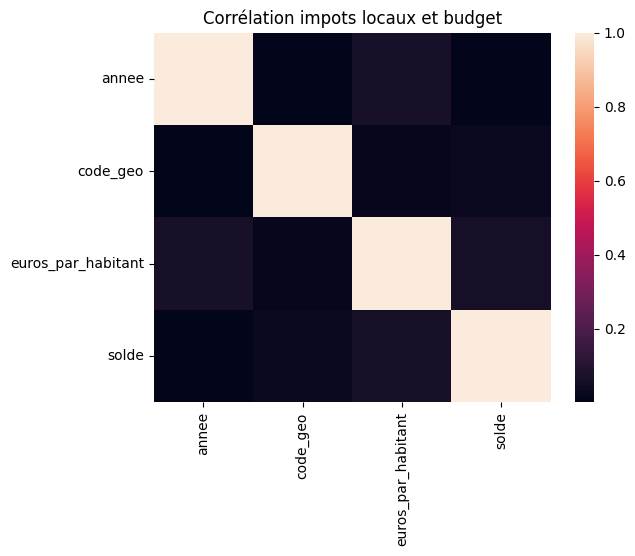

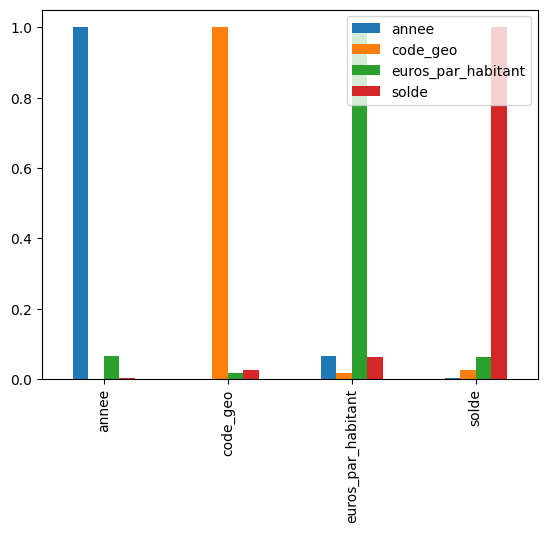

In [17]:
sns.heatmap(depenses_corr)
plt.title("Corrélation impots locaux et budget")
plt.show()

depenses_corr.plot(kind = "bar")
plt.show()

In [18]:
dettes = budget[budget["type_compte"] == "dettes"]
dettes["annee"].value_counts()

annee
2020    48895
2021    48595
2022    48450
2023    48048
2024    47633
Name: count, dtype: int64

In [19]:
dettes_merge = impots.merge(dettes, on = ["code_geo","annee"])

dettes_merge["annee"].value_counts()

annee
2022    34204
2023    34165
2021    34155
2020    34046
2024    33509
Name: count, dtype: int64

In [20]:
impots_dettes = dettes_merge[["annee", "code_geo","euros_par_habitant", "solde"]]
impots_dettes.head()

,annee,code_geo,euros_par_habitant,solde
0,2020,55246,112.149660,-221792.39
1,2020,55245,118.362069,-683730.77
2,2020,55244,63.318182,-102025.77
3,2020,55243,100.048649,-23316.35
4,2020,55242,275.528870,-89251.89


In [21]:
dettes_corr = impots_dettes.corr()
dettes_corr

,annee,code_geo,euros_par_habitant,solde
annee,1.000000,0.00160,0.064799,-0.000457
code_geo,0.001600,1.00000,0.016180,-0.017850
euros_par_habitant,0.064799,0.01618,1.000000,-0.043710
solde,-0.000457,-0.01785,-0.043710,1.000000


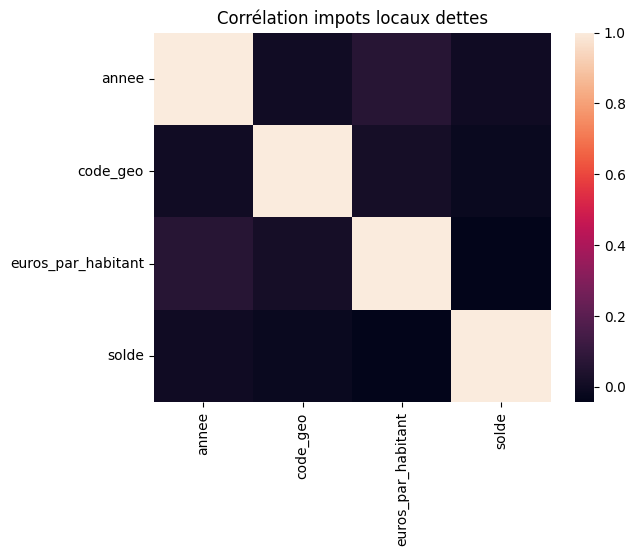

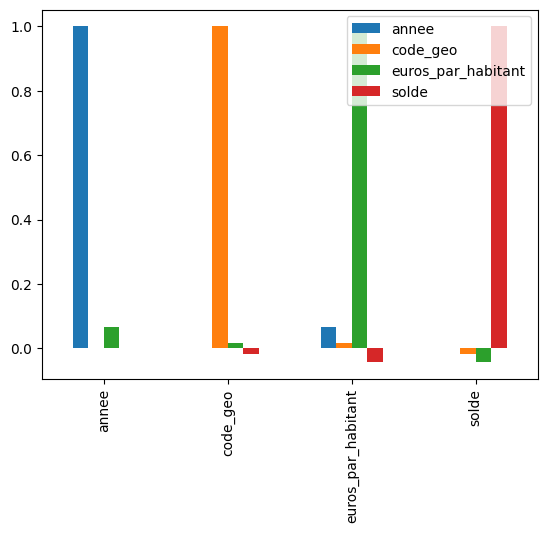

In [22]:
sns.heatmap(dettes_corr)
plt.title("Corrélation impots locaux dettes")
plt.show()

dettes_corr.plot(kind = "bar")
plt.show()

<h1 style= "text-align:center; color:green">Evolution des Impots Locaux de 2020 à 2024</h1>

In [23]:
geo = df.copy()

In [24]:
impots["annee"].value_counts()

annee
2020    34967
2021    34964
2022    34951
2023    34940
2024    34931
Name: count, dtype: int64

In [25]:
impots.head()

,annee,code_geo,com_name,agregat,montant,ptot,euros_par_habitant
35459,2020,55246,Hévilliers,Impôts locaux,16486.00,147.0,112.149660
35458,2020,55245,Heudicourt-sous-les-Côtes,Impôts locaux,20595.00,174.0,118.362069
35457,2020,55244,Herméville-en-Woëvre,Impôts locaux,15323.00,242.0,63.318182
35456,2020,55243,Herbeuville,Impôts locaux,18509.00,185.0,100.048649
35455,2020,55242,Hennemont,Impôts locaux,31685.82,115.0,275.528870


In [26]:
evolution = impots[impots["annee"].isin([2020, 2024])]
evolution["annee"].value_counts()

annee
2020    34967
2024    34931
Name: count, dtype: int64

In [27]:
df_pivot = evolution.pivot_table(
    index="code_geo",
    columns="annee",
    values="euros_par_habitant",
   
)
df_pivot.head(2)

annee,2020,2024
code_geo,,
01001,272.350126,325.067217
01002,445.476345,459.412491


In [28]:
df_pivot["evolution_percent"] = (df_pivot[2024] - df_pivot[2020]) / df_pivot[2020] *100
df_pivot["evolution_percent"] = df_pivot["evolution_percent"].round(2)
df_pivot.head(2)

annee,2020,2024,evolution_percent
code_geo,,,
01001,272.350126,325.067217,19.36
01002,445.476345,459.412491,3.13


In [29]:
df_merge = df_pivot.merge(geo, on = "code_geo")
df_merge.head(2)

,code_geo,2020,2024,evolution_percent,nom_commune,code_geo_actuel,nom_commune_majuscule,nom_commune_minuscule,code_zone_superficie,type_commune,...,code_arrondissement_departemental,nom_arrondissement_departemental,code_epci,nom_epci,code_zone_emploi_2020,nom_zone_emploi_2020,code_bassin_vie_2022,nom_bassin_vie_2022,geo_point_2_d,geometry
0,01001,272.350126,325.067217,19.36,L'Abergement-Clémenciat,01001,L'ABERGEMENT-CLÉMENCIAT,l'abergement-clémenciat,FXX,commune,...,012,Bourg-en-Bresse,200069193,Communauté de communes de la Dombes,8405,Bourg-en-Bresse,01093,Châtillon-sur-Chalaronne,"{ ""lon"": 4.9258526221852108, ""lat"": 46.1537202...","POLYGON ((4.95841160881725 46.15327332986996, ..."
1,01002,445.476345,459.412491,3.13,L'Abergement-de-Varey,01002,L'ABERGEMENT-DE-VAREY,l'abergement-de-varey,FXX,commune,...,011,Belley,240100883,Communauté de communes de la Plaine de l'Ain,8405,Bourg-en-Bresse,01004,Ambérieu-en-Bugey,"{ ""lon"": 5.4280882780405175, ""lat"": 46.0096049...","POLYGON ((5.430202371422386 45.98277466337263,..."


In [30]:
df_merge["geometry"] = df_merge["geometry"].apply(
    lambda x: wkt.loads(x) if isinstance(x, str) else x
)

# Création du GeoDataFrame
gdf = gpd.GeoDataFrame(df_merge, geometry="geometry")

# Métropole + Corse
mask_drom = gdf["code_geo"].str.startswith(("97", "98"))

gdf_impots = gdf[~mask_drom]
gdf_impots_drom = gdf[mask_drom]

In [31]:
gdf_impots.head(2)

,code_geo,2020,2024,evolution_percent,nom_commune,code_geo_actuel,nom_commune_majuscule,nom_commune_minuscule,code_zone_superficie,type_commune,...,code_arrondissement_departemental,nom_arrondissement_departemental,code_epci,nom_epci,code_zone_emploi_2020,nom_zone_emploi_2020,code_bassin_vie_2022,nom_bassin_vie_2022,geo_point_2_d,geometry
0,01001,272.350126,325.067217,19.36,L'Abergement-Clémenciat,01001,L'ABERGEMENT-CLÉMENCIAT,l'abergement-clémenciat,FXX,commune,...,012,Bourg-en-Bresse,200069193,Communauté de communes de la Dombes,8405,Bourg-en-Bresse,01093,Châtillon-sur-Chalaronne,"{ ""lon"": 4.9258526221852108, ""lat"": 46.1537202...","POLYGON ((4.95841 46.15327, 4.95783 46.15351, ..."
1,01002,445.476345,459.412491,3.13,L'Abergement-de-Varey,01002,L'ABERGEMENT-DE-VAREY,l'abergement-de-varey,FXX,commune,...,011,Belley,240100883,Communauté de communes de la Plaine de l'Ain,8405,Bourg-en-Bresse,01004,Ambérieu-en-Bugey,"{ ""lon"": 5.4280882780405175, ""lat"": 46.0096049...","POLYGON ((5.4302 45.98277, 5.43369 45.98393, 5..."


In [32]:
a = gdf_impots[gdf_impots["evolution_percent"] <= 0]
b = gdf_impots[(gdf_impots["evolution_percent"] > 0) & gdf_impots["evolution_percent"] < 100]
c = gdf_impots[gdf_impots["evolution_percent"] >= 100]

print("évolution négative", a.shape)
print("évolution comprise entre 0 et 100%", b.shape)
print("évolution > à 100 %", c.shape)

évolution négative (3183, 26)
évolution comprise entre 0 et 100% (34732, 26)
évolution > à 100 % (1376, 26)


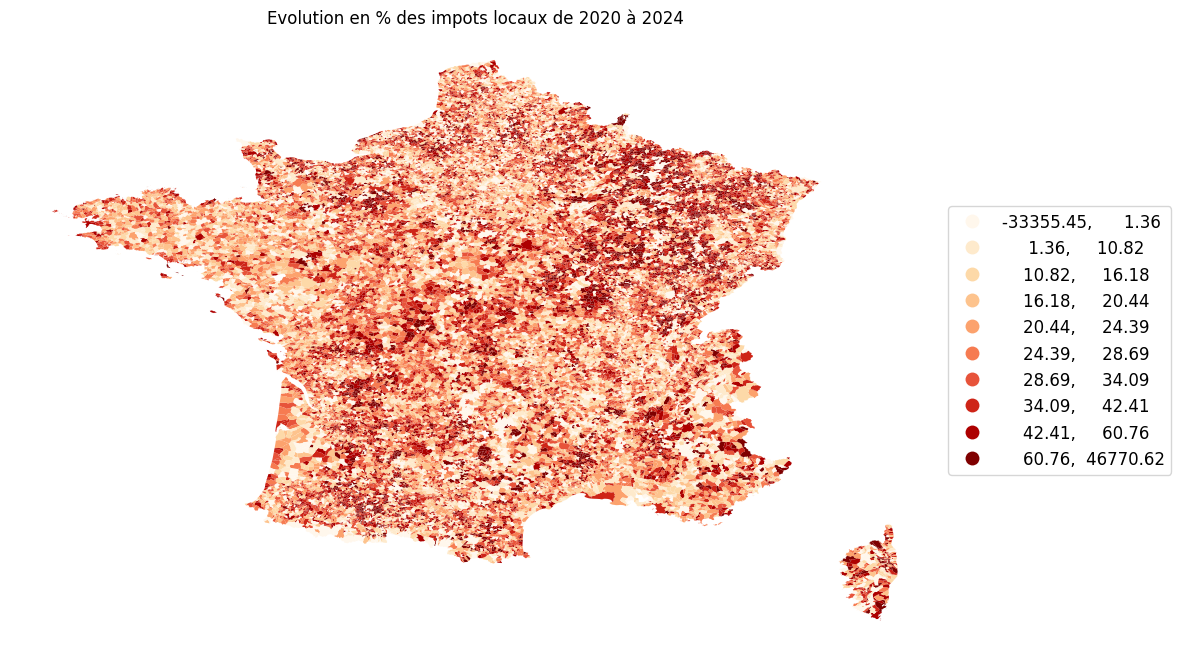

In [33]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_impots.plot(
    column="evolution_percent",
    scheme="quantiles",
    k=10,
    cmap="OrRd",
    legend=True,
    ax=ax,
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1, 0.5),  # à droite de la carte
        "fontsize": 12
    }
)



ax.set_title("Evolution en % des impots locaux de 2020 à 2024")
ax.axis("off")

plt.show()

<Axes: >

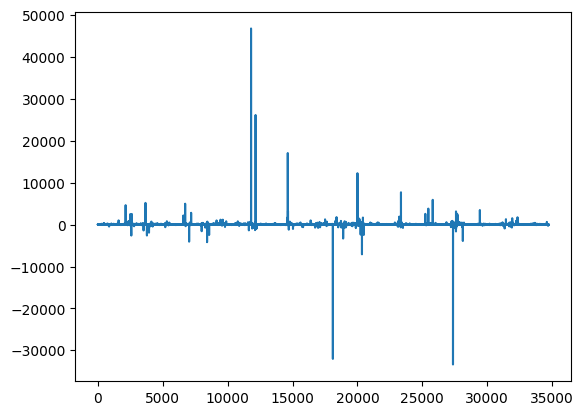

In [34]:
gdf_impots["evolution_percent"].plot()

In [35]:
gdf_impots["evolution_percent"].describe()

count    34725.000000
mean        32.027958
std        417.847889
min     -33355.450000
25%         13.700000
50%         24.390000
75%         37.690000
max      46770.620000
Name: evolution_percent, dtype: float64

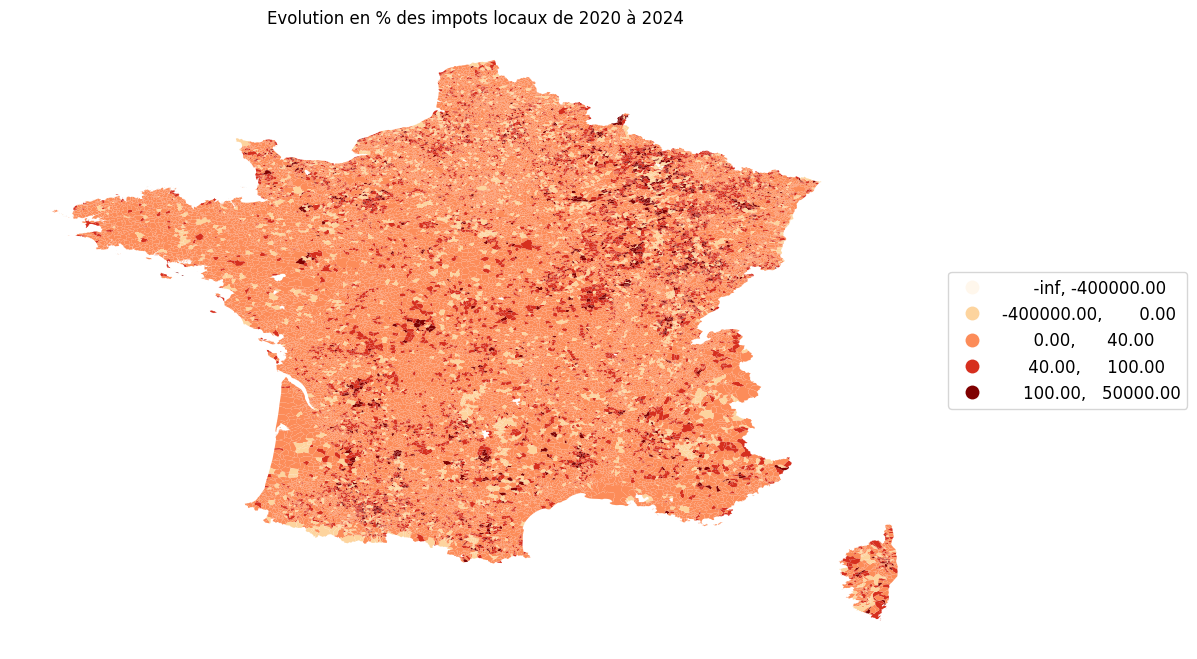

In [36]:
bins = [-400000, 0, 40, 100, 50000]


fig, ax = plt.subplots(figsize=(12, 10))

gdf_impots.plot(
    column="evolution_percent",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    cmap="OrRd",
    legend=True,
    ax=ax,
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1, 0.5),
        "fontsize": 12
    }
)

ax.set_title("Evolution en % des impots locaux de 2020 à 2024")
ax.axis("off")

plt.show()

In [38]:
gdf_impots_drom["evolution_percent"].describe()

count    128.000000
mean      30.626953
std       78.618667
min      -75.430000
25%        9.090000
50%       20.720000
75%       33.565000
max      672.460000
Name: evolution_percent, dtype: float64

In [39]:
gdf_impots_drom["code_zone_superficie"].unique()

array(['GLP', 'MTQ', 'GUF', 'REU', 'MYT'], dtype=object)

In [40]:
guadeloupe = gdf_impots_drom[gdf_impots_drom["code_zone_superficie"] == "GLP"]
martinique = gdf_impots_drom[gdf_impots_drom["code_zone_superficie"] == "MTQ"]
guyane = gdf_impots_drom[gdf_impots_drom["code_zone_superficie"] == "GUF"]
reunion = gdf_impots_drom[gdf_impots_drom["code_zone_superficie"] == "REU"]
mayotte = gdf_impots_drom[gdf_impots_drom["code_zone_superficie"] == "MYT"]

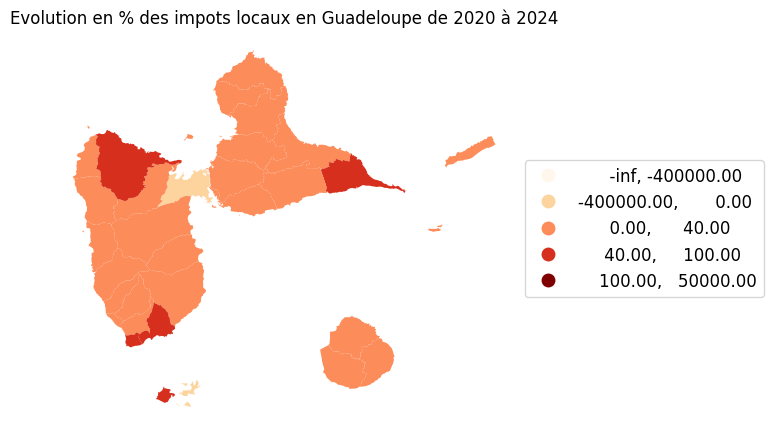

In [41]:
fig, ax = plt.subplots(figsize=(6, 6))

guadeloupe.plot(
    column="evolution_percent",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    cmap="OrRd",
    legend=True,
    ax=ax,
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1, 0.5),
        "fontsize": 12
    }
)

ax.set_title("Evolution en % des impots locaux en Guadeloupe de 2020 à 2024")
ax.axis("off")

plt.show()

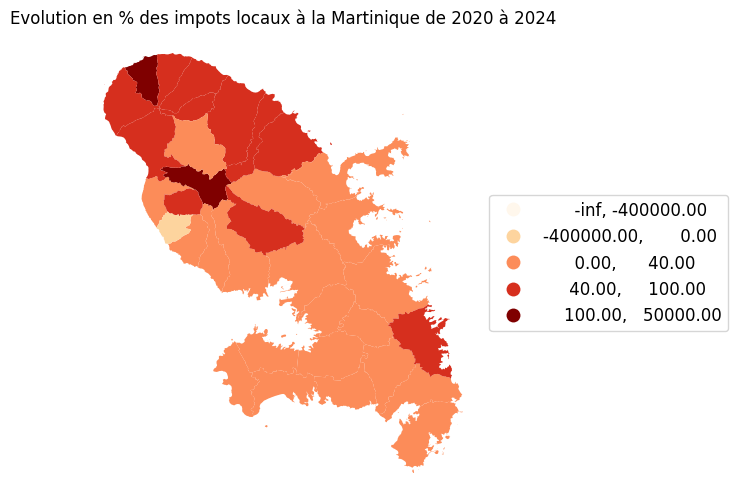

In [42]:
fig, ax = plt.subplots(figsize=(6, 6))

martinique.plot(
    column="evolution_percent",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    cmap="OrRd",
    legend=True,
    ax=ax,
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1, 0.5),
        "fontsize": 12
    }
)

ax.set_title("Evolution en % des impots locaux à la Martinique de 2020 à 2024")
ax.axis("off")

plt.show()

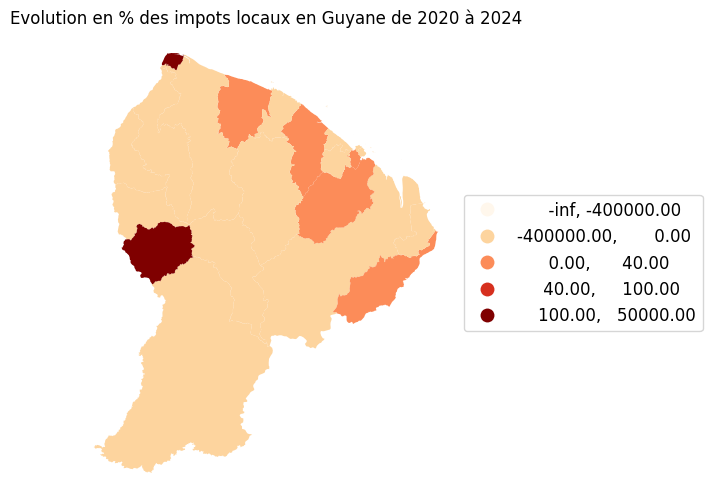

In [43]:
fig, ax = plt.subplots(figsize=(6, 6))

guyane.plot(
    column="evolution_percent",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    cmap="OrRd",
    legend=True,
    ax=ax,
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1, 0.5),
        "fontsize": 12
    }
)

ax.set_title("Evolution en % des impots locaux en Guyane de 2020 à 2024")
ax.axis("off")

plt.show()

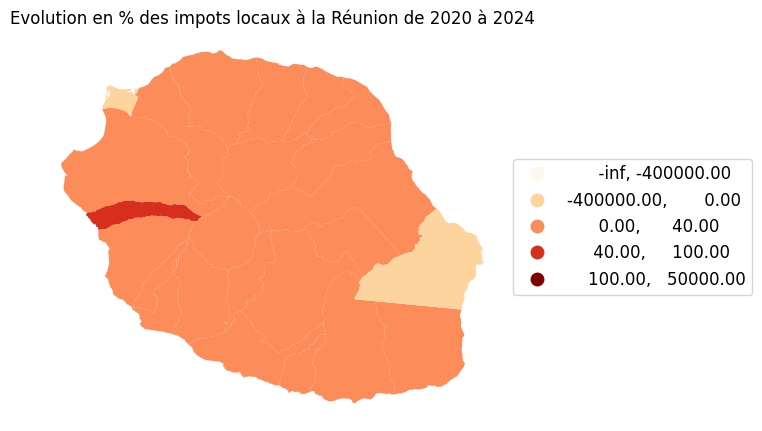

In [44]:
fig, ax = plt.subplots(figsize=(6, 6))

reunion.plot(
    column="evolution_percent",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    cmap="OrRd",
    legend=True,
    ax=ax,
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1, 0.5),
        "fontsize": 12
    }
)

ax.set_title("Evolution en % des impots locaux à la Réunion de 2020 à 2024")
ax.axis("off")

plt.show()

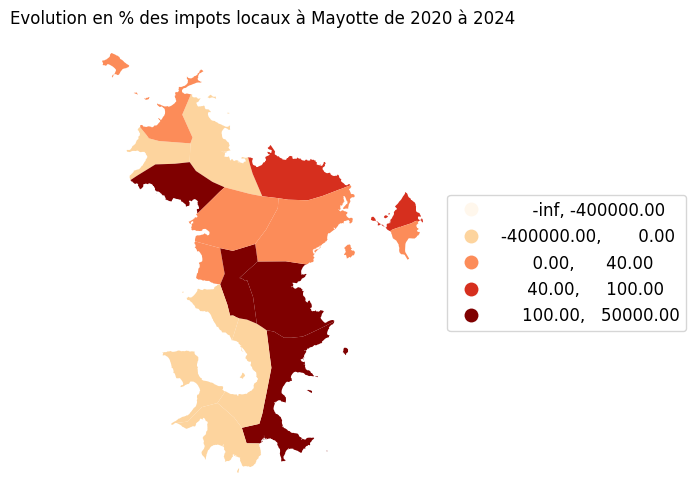

In [45]:
fig, ax = plt.subplots(figsize=(6, 6))

mayotte.plot(
    column="evolution_percent",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    cmap="OrRd",
    legend=True,
    ax=ax,
    legend_kwds={
        "loc": "center left",
        "bbox_to_anchor": (1, 0.5),
        "fontsize": 12
    }
)

ax.set_title("Evolution en % des impots locaux à Mayotte de 2020 à 2024")
ax.axis("off")

plt.show()